In [234]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from statsmodels.tsa.seasonal import seasonal_decompose, STL

# 시계열 데이터 분석

목적 : 시계열 자료를 이용하여 미래 예측

미래 예측은 시계열 모형을 통해 구현

모형은 공통의 특성을 수학적으로 구현한 것

관측치의 분포가 동일해야 공통의 특성을 끄집어내 모형을 만들 수 있음

관측치가 동일한 분포에서 생성된 것이라면 평균과 분산은 시간과 무관

특징

시계열 자료에선 순서가 있다 모델링 할 때 이 순서를 변경해서는 안된다.

시계열 자료 자체만을 이용해 예측할 수 있다.

용어

level  : 일정 시간 구간에서의 시계열 평균

trend: 시계열의 전반적인 증가 및 감소 추세

seasonality: 시계열 반복 주기, 계절성

noise: 정상성을 만족하는 시계열, 이 중 설명 불가능한 것을 백색소음이라 한다.

residual : noise의 추정치

# 시계열 분해

추세, 계절성 잔차로 분리하는 절차 -> 주로 그래프로 표현

추세(Trend, T, Level이라고도 함)
- 시계열에서 느리지만 장기적인 변화, 증가/감소
- 이동평균법을 이용

계절성
- 계절적

# 차분

- 관측값 사이의 차이 값을 말한다.
- 1차 차분
$$\triangle X_t = X_t - X_{t-1}$$
- 계절 차분 (월별 데이터에서 연간 주기성 s=12)
$$\triangle X_t = X_t - X_{t-s}$$

Reg, ARIMA

In [235]:
df = pd.read_csv('https://raw.githubusercontent.com/marcopeix/AppliedTimeSeriesAnalysisWithPython/main/data/jj.csv')

In [236]:
df.head(), df.tail()

(         date  data
 0  1960-01-01  0.71
 1  1960-04-01  0.63
 2  1960-07-02  0.85
 3  1960-10-01  0.44
 4  1961-01-01  0.61,
           date   data
 79  1979-10-01   9.99
 80  1980-01-01  16.20
 81  1980-04-01  14.67
 82  1980-07-02  16.02
 83  1980-10-01  11.61)

In [237]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 84 entries, 0 to 83
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   date    84 non-null     object 
 1   data    84 non-null     float64
dtypes: float64(1), object(1)
memory usage: 1.4+ KB


In [238]:
df['year'] = pd.DatetimeIndex(df['date']).year

In [239]:
df

,date,data,year
0,1960-01-01,0.71,1960
1,1960-04-01,0.63,1960
2,1960-07-02,0.85,1960
3,1960-10-01,0.44,1960
4,1961-01-01,0.61,1961
...,...,...,...
79,1979-10-01,9.99,1979
80,1980-01-01,16.20,1980
81,1980-04-01,14.67,1980
82,1980-07-02,16.02,1980


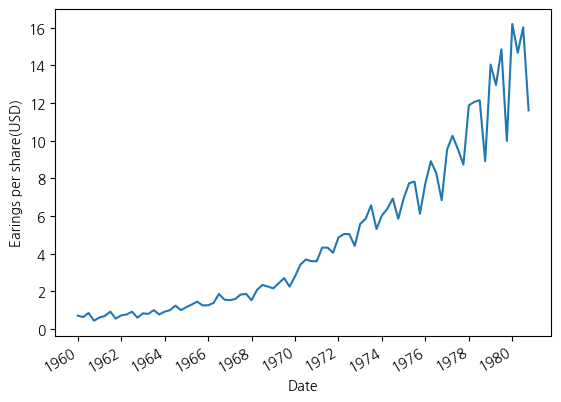

In [240]:
fig, ax = plt.subplots()

ax.plot(df.date, df.data)
ax.set_xlabel('Date')
ax.set_ylabel('Earings per share(USD)')
plt.xticks(np.arange(0, 85, 8), [1960, 1962, 1964, 1966, 1968, 1970, 1972, 1974, 1976, 1978, 1980])
fig.autofmt_xdate()
plt.show()

In [241]:
# rolling 씀
moving_average = df['data'].rolling(window=4).mean()

In [242]:
moving_average

,data
0,NaN
1,NaN
2,NaN
3,0.6575
4,0.6325
...,...
79,12.9600
80,13.5000
81,13.9275
82,14.2200


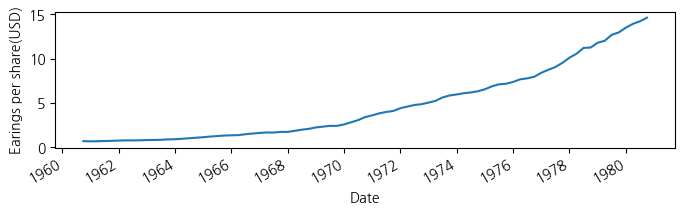

In [243]:
# 추세 그래프
fig, ax = plt.subplots(figsize=(8, 2))

ax.plot(df.date, moving_average)
ax.set_xlabel('Date')
ax.set_ylabel('Earings per share(USD)')
plt.xticks(np.arange(0, 85, 8), [1960, 1962, 1964, 1966, 1968, 1970, 1972, 1974, 1976, 1978, 1980])
fig.autofmt_xdate()
plt.show()

In [244]:
# 시계열 분석 해준다
adv_decom = STL(df.data, period=4).fit()

Text(0, 0.5, 'Residuals')

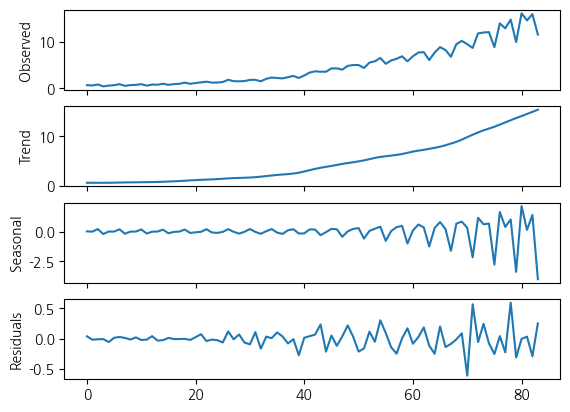

In [245]:
fig, (ax1, ax2, ax3, ax4) = plt.subplots(nrows=4, ncols=1, sharex=True)

ax1.plot(adv_decom.observed)
ax1.set_ylabel('Observed')

ax2.plot(adv_decom.trend)
ax2.set_ylabel('Trend')

ax3.plot(adv_decom.seasonal)
ax3.set_ylabel('Seasonal')

ax4.plot(adv_decom.resid)
ax4.set_ylabel('Residuals')

In [246]:
!ls ./drive/MyDrive/data/A*.csv

./drive/MyDrive/data/AirPassengers.csv


In [247]:
df = pd.read_csv('./drive/MyDrive/data/AirPassengers.csv', parse_dates=['Month'])

In [248]:
df.head()

,Month,Passengers
0,1949-01-01,112
1,1949-02-01,118
2,1949-03-01,132
3,1949-04-01,129
4,1949-05-01,121


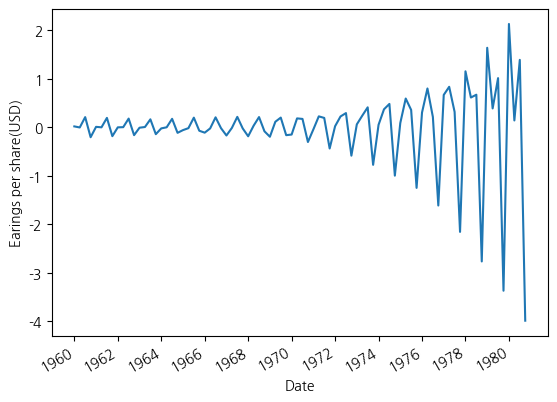

In [249]:
fig, ax = plt.subplots()

ax.plot(adv_decom.seasonal)
ax.set_xlabel('Date')
ax.set_ylabel('Earings per share(USD)')
plt.xticks(np.arange(0, 85, 8), [1960, 1962, 1964, 1966, 1968, 1970, 1972, 1974, 1976, 1978, 1980])
fig.autofmt_xdate()
plt.show()

In [250]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 144 entries, 0 to 143
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   Month       144 non-null    datetime64[ns]
 1   Passengers  144 non-null    int64         
dtypes: datetime64[ns](1), int64(1)
memory usage: 2.4 KB


In [251]:
df

,Month,Passengers
0,1949-01-01,112
1,1949-02-01,118
2,1949-03-01,132
3,1949-04-01,129
4,1949-05-01,121
...,...,...
139,1960-08-01,606
140,1960-09-01,508
141,1960-10-01,461
142,1960-11-01,390


In [252]:
df.head(12)

,Month,Passengers
0,1949-01-01,112
1,1949-02-01,118
2,1949-03-01,132
3,1949-04-01,129
4,1949-05-01,121
5,1949-06-01,135
6,1949-07-01,148
7,1949-08-01,148
8,1949-09-01,136
9,1949-10-01,119


In [253]:
df.iloc[:12].mean()

,0
Month,1949-06-16 12:00:00
Passengers,126.666667


In [254]:
for i in range(len(df)):
    print(i-5)

-5
-4
-3
-2
-1
0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
50
51
52
53
54
55
56
57
58
59
60
61
62
63
64
65
66
67
68
69
70
71
72
73
74
75
76
77
78
79
80
81
82
83
84
85
86
87
88
89
90
91
92
93
94
95
96
97
98
99
100
101
102
103
104
105
106
107
108
109
110
111
112
113
114
115
116
117
118
119
120
121
122
123
124
125
126
127
128
129
130
131
132
133
134
135
136
137
138


In [255]:
df = pd.read_csv('./drive/MyDrive/data/AirPassengers.csv', parse_dates=['Month'], index_col='Month')

In [256]:
df.index.freq = 'MS'

In [257]:
df

,Passengers
Month,
1949-01-01,112
1949-02-01,118
1949-03-01,132
1949-04-01,129
1949-05-01,121
...,...
1960-08-01,606
1960-09-01,508
1960-10-01,461


In [258]:
result = seasonal_decompose(df['Passengers'], model='multiplicative', period=12)

In [259]:
result.resid.head(10)

,resid
Month,
1949-01-01,NaN
1949-02-01,NaN
1949-03-01,NaN
1949-04-01,NaN
1949-05-01,NaN
1949-06-01,NaN
1949-07-01,0.951664
1949-08-01,0.953401
1949-09-01,1.002220


In [260]:
ma12 = df['Passengers'].rolling(window=12, center=True).mean()
ma11 = df['Passengers'].shift(-1).rolling(window=12, center=True).mean()
trend_manual = (ma12 + ma11) / 2

In [261]:
detrended = df['Passengers'] / trend_manual

In [262]:
detrended.head(10)

,Passengers
Month,
1949-01-01,NaN
1949-02-01,NaN
1949-03-01,NaN
1949-04-01,NaN
1949-05-01,NaN
1949-06-01,NaN
1949-07-01,1.167269
1949-08-01,1.163065
1949-09-01,1.062846


In [263]:
seasonal_manual = detrended.groupby(detrended.index.month).transform('mean')
residual_manual = df['Passengers'] / (trend_manual * seasonal_manual)

In [264]:
detrended.head(40)

,Passengers
Month,
1949-01-01,NaN
1949-02-01,NaN
1949-03-01,NaN
1949-04-01,NaN
1949-05-01,NaN
1949-06-01,NaN
1949-07-01,1.167269
1949-08-01,1.163065
1949-09-01,1.062846


In [265]:
comparison = pd.DataFrame({
    'statsmodels': result.resid,
    'manual': residual_manual,
    'diff': (result.resid - residual_manual).abs()}).dropna()

print(comparison.head().to_string())
print(f'\n 최대 오차: {comparison['diff'].max():.2e}')

            statsmodels    manual      diff
Month                                      
1949-07-01     0.951664  0.953346  0.001682
1949-08-01     0.953401  0.955087  0.001685
1949-09-01     1.002220  1.003991  0.001771
1949-10-01     1.004028  1.005802  0.001775
1949-11-01     1.006270  1.008049  0.001779

 최대 오차: 1.93e-03


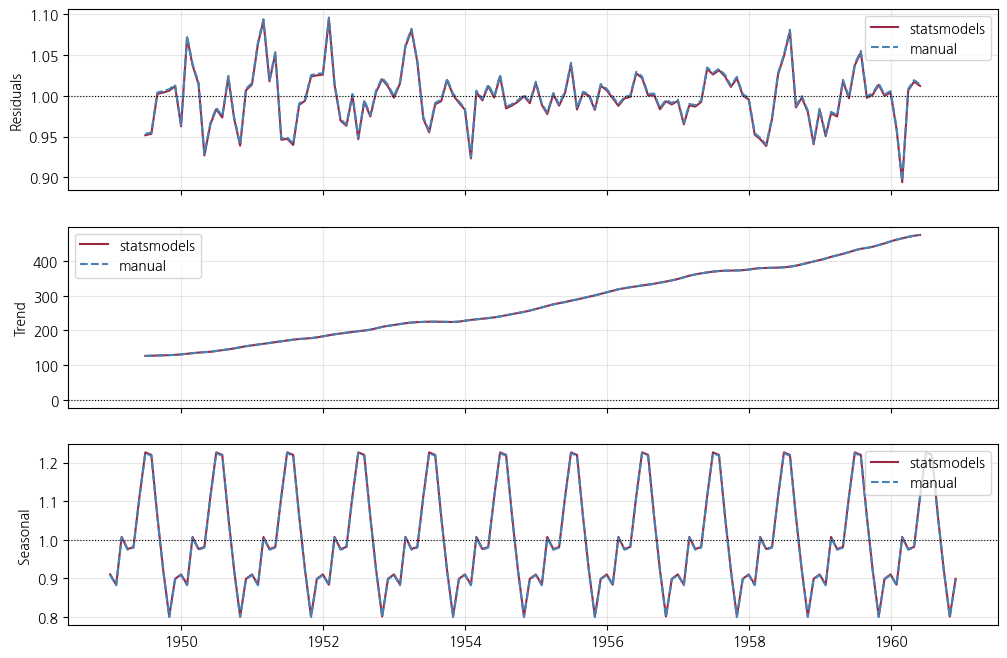

In [266]:
fig, axes = plt.subplots(3, 1, figsize=(12, 8), sharex=True)

axes[0].plot(result.resid, label='statsmodels', color='#9b2743', linewidth=1.5)
axes[0].plot(residual_manual, label='manual', color='steelblue', linewidth=1.5, linestyle='--')
axes[0].axhline(1, color='k', linestyle=':', linewidth=0.8)
axes[0].set_ylabel('Residuals')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(result.trend, label='statsmodels', color='#9b2743', linewidth=1.5)
axes[1].plot(trend_manual, label='manual', color='steelblue', linewidth=1.5, linestyle='--')
axes[1].axhline(1, color='k', linestyle=':', linewidth=0.8)
axes[1].set_ylabel('Trend')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

axes[2].plot(result.seasonal, label='statsmodels', color='#9b2743', linewidth=1.5)
axes[2].plot(seasonal_manual, label='manual', color='steelblue', linewidth=1.5, linestyle='--')
axes[2].axhline(1, color='k', linestyle=':', linewidth=0.8)
axes[2].set_ylabel('Seasonal')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

In [267]:
y = df['Passengers']

In [268]:
y

,Passengers
Month,
1949-01-01,112
1949-02-01,118
1949-03-01,132
1949-04-01,129
1949-05-01,121
...,...
1960-08-01,606
1960-09-01,508
1960-10-01,461


In [269]:
!pip install koreanize-matplotlib

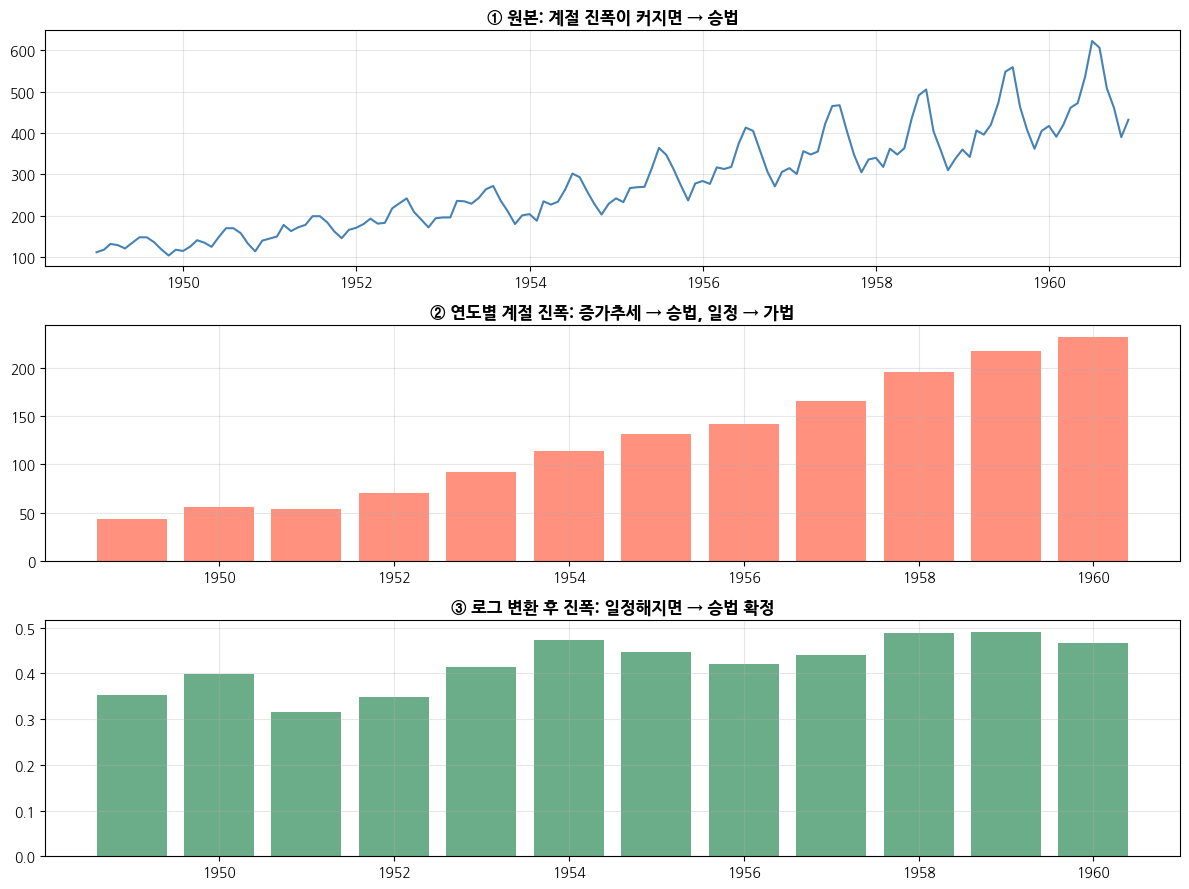

In [270]:
import koreanize_matplotlib
fig, axes = plt.subplots(3, 1, figsize=(12, 9))
# 1. 원본 시계열 - 계절 진폭 확인
axes[0].plot(y, color='steelblue', linewidth=1.5)
axes[0].set_title('① 원본: 계절 진폭이 커지면 → 승법', fontweight='bold')
axes[0].grid(True, alpha=0.3)

# 2. 연도별 계절 진폭 계산 (max - min)
amplitude = y.groupby(y.index.year).apply(lambda g: g.max() - g.min())
axes[1].bar(amplitude.index, amplitude.values, color='tomato', alpha=0.7)
axes[1].set_title('② 연도별 계절 진폭: 증가추세 → 승법, 일정 → 가법', fontweight='bold')
axes[1].grid(True, alpha=0.3)

# 3. 로그 변환 후 계절 진폭
log_amplitude = np.log(y).groupby(y.index.year).apply(lambda g: g.max() - g.min())
axes[2].bar(log_amplitude.index, log_amplitude.values, color='seagreen', alpha=0.7)
axes[2].set_title('③ 로그 변환 후 진폭: 일정해지면 → 승법 확정', fontweight='bold')
axes[2].grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('additive_vs_multiplicative.png', dpi=150, bbox_inches='tight')
plt.show()

# ADF
시계열에 단위근 unit root이 있는지 여부를 조사

$$y_t = C + ø y_{t-1} + \epsilon_t$$

## 정상성 테스트

In [271]:
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

In [272]:
residual_manual.head(10)

,Passengers
Month,
1949-01-01,NaN
1949-02-01,NaN
1949-03-01,NaN
1949-04-01,NaN
1949-05-01,NaN
1949-06-01,NaN
1949-07-01,0.953346
1949-08-01,0.955087
1949-09-01,1.003991


In [273]:
ADF_result = adfuller(residual_manual.dropna())

In [274]:
ADF_result[0], ADF_result[1]

(np.float64(-7.415924640885234), np.float64(6.936028992598549e-11))

In [275]:
np.random.seed(42)
steps = np.random.standard_normal(1000)
steps[0] = 0
random_walk = np.cumsum(steps)

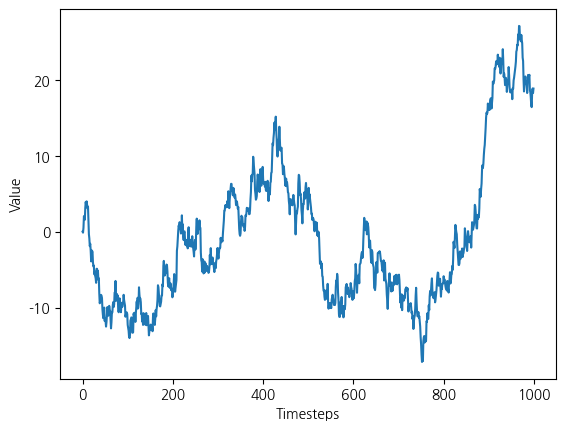

In [276]:
fig, ax = plt.subplots()
ax.plot(random_walk)
ax.set_xlabel('Timesteps')
ax.set_ylabel('Value')
plt.show()

In [277]:
ADF_result = adfuller(random_walk)
print(f'ADF Statistic: {ADF_result[0]}')
print(f'p-value: {ADF_result[1]}')

ADF Statistic: -0.965952487691875
p-value: 0.7654789696692581


In [278]:
def ex_simulate_process(is_stationary):
    np.random.seed(42)
    process = np.empty(400)

    if is_stationary:
        alpha = 0.5
        process[0] = 0.1
    else:
        alpha = 1
        process[0] = 1.3

    for i in range(400):
        if i+1 < 400:
            process[i+1] = alpha * process[i] + 0.1
        else:
            break
    return process

In [279]:
ex_stationary = ex_simulate_process(is_stationary=True)
ex_nonstationary = ex_simulate_process(is_stationary=False)

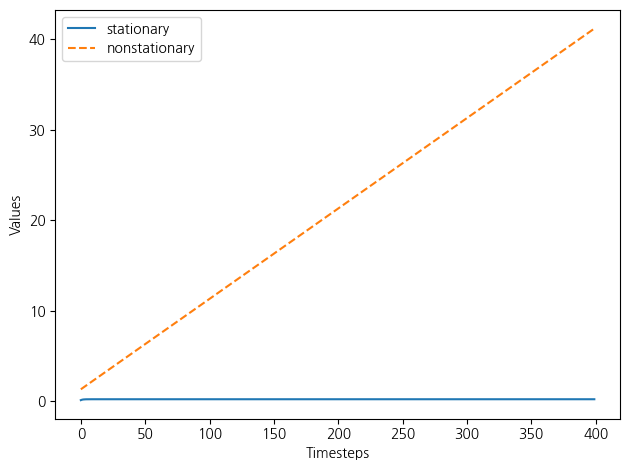

In [280]:
fig, ax = plt.subplots()

ax.plot(ex_stationary, label='stationary', linestyle='-')
ax.plot(ex_nonstationary, label='nonstationary', linestyle='--')
ax.set_xlabel('Timesteps')
ax.set_ylabel('Values')
ax.legend(loc=2)

plt.tight_layout()

단위근 검정에서 오차향이 있는경우

$$
y_t = 0.5_{y_{t-1}} + \epsilon_t
$$

In [281]:
def simulate_process(is_stationary):
    np.random.seed(42)
    process = np.empty(400)

    if is_stationary:
        alpha = 0.5
        process[0] = 0
    else:
        alpha = 1
        process[0] = 10

    for i in range(400):
        if i+1 < 400:
            process[i+1] = alpha * process[i] + np.random.standard_normal()
        else:
            break
    return process

In [282]:
stationary = simulate_process(is_stationary=True)
nonstationary = simulate_process(is_stationary=False)

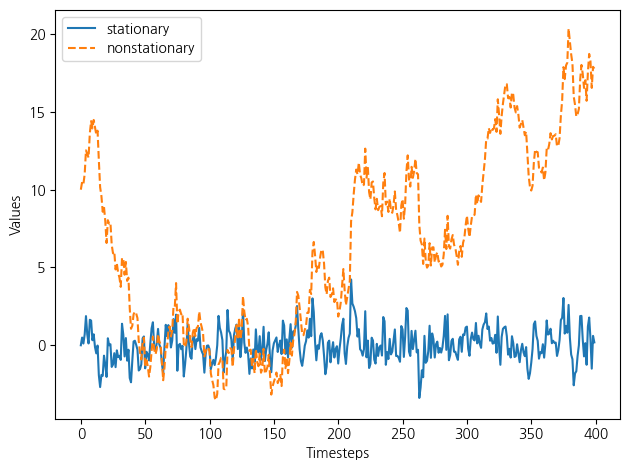

In [283]:
fig, ax = plt.subplots()

ax.plot(stationary, label='stationary', linestyle='-')
ax.plot(nonstationary, label='nonstationary', linestyle='--')
ax.set_xlabel('Timesteps')
ax.set_ylabel('Values')
ax.legend(loc=2)

plt.tight_layout()

# 확률 보행의 특징
- 차분이 정상적이고 상관관계가 없는 시계열 이다.
- 원본 시계열이 비정상적이다 -> 차분하여 정상적으로 변환
- 차분: 현재 데이터와 과거 데이터의 차이

In [284]:
# 누적시간평균함수
def mean_over_time(process):
    mean_func = []
    for i in range(len(process)):
        mean_func.append(np.mean(process[:i]))
    return mean_func

In [285]:
stationary_mean = mean_over_time(stationary)
nonstationary_mean = mean_over_time(nonstationary)

/usr/local/lib/python3.12/dist-packages/numpy/_core/fromnumeric.py:3596: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/usr/local/lib/python3.12/dist-packages/numpy/_core/_methods.py:138: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


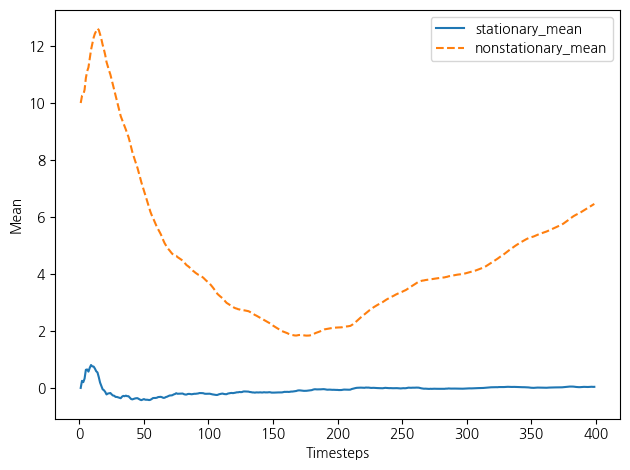

In [286]:
fig, ax = plt.subplots()

ax.plot(stationary_mean, label='stationary_mean', linestyle='-')
ax.plot(nonstationary_mean, label='nonstationary_mean', linestyle='--')
ax.set_xlabel('Timesteps')
ax.set_ylabel('Mean')
ax.legend(loc=1)

plt.tight_layout()

In [287]:
def var_over_time(process):
    var_func = []
    for i in range(len(process)):
        var_func.append(np.var(process[:i]))

    return var_func

In [288]:
stationary_var = var_over_time(stationary)
nonstationary_var = var_over_time(nonstationary)

/usr/local/lib/python3.12/dist-packages/numpy/_core/fromnumeric.py:4008: RuntimeWarning: Degrees of freedom <= 0 for slice
  return _methods._var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/usr/local/lib/python3.12/dist-packages/numpy/_core/_methods.py:175: RuntimeWarning: invalid value encountered in divide
  arrmean = um.true_divide(arrmean, div, out=arrmean,
/usr/local/lib/python3.12/dist-packages/numpy/_core/_methods.py:210: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


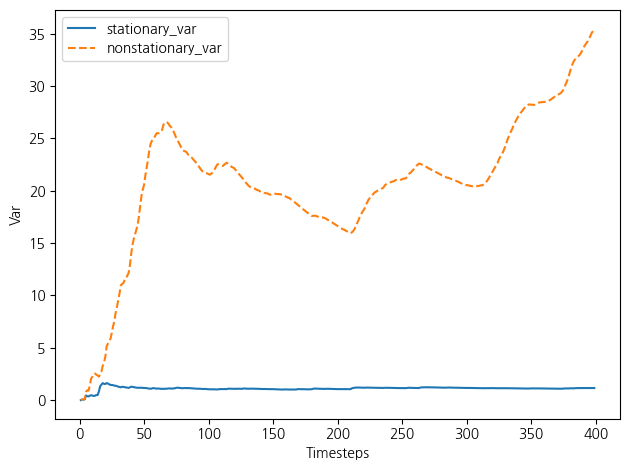

In [289]:
fig, ax = plt.subplots()

ax.plot(stationary_var, label='stationary_var', linestyle='-')
ax.plot(nonstationary_var, label='nonstationary_var', linestyle='--')
ax.set_xlabel('Timesteps')
ax.set_ylabel('Var')
ax.legend(loc=2)

plt.tight_layout()

In [290]:
ADF_result = adfuller(random_walk)
ADF_result[0], ADF_result[1]

(np.float64(-0.965952487691875), np.float64(0.7654789696692581))

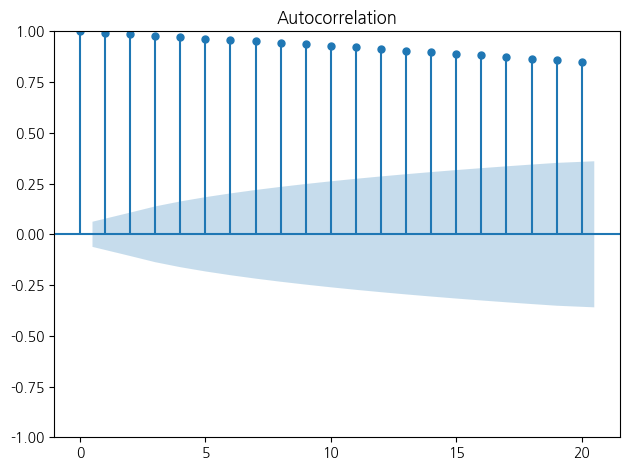

In [291]:
plot_acf(random_walk, lags=20);
plt.tight_layout()

In [292]:
# 다음꺼로 차분
diff_random_walk = np.diff(random_walk, n=1)

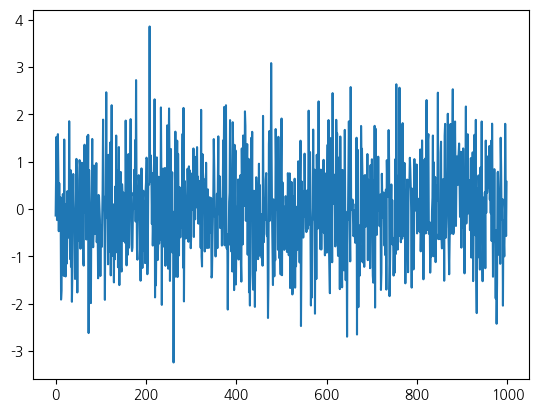

In [293]:
plt.plot(diff_random_walk)

In [294]:
ADF_result = adfuller(diff_random_walk)
ADF_result[0], ADF_result[1] # 검정통계량 , p-value

(np.float64(-31.789310857560594), 0.0)

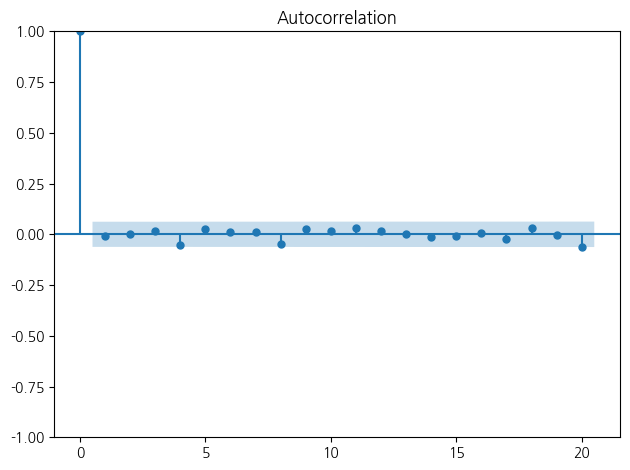

In [295]:
# 자기상관계수 그래프
plot_acf(diff_random_walk, lags=20);
plt.tight_layout()

# Baseline model

- Baseline model은 예측 문제를 해결하기 위한 훌령하지 않은 가장 단순한 모델

- Baseline model 만드는 방법
    - 학습(train)을 사용해 모델을 만들지 않는다.
    - 상수 사용: 평균값, 마지막 값, 마지막 기간 평균값 등을 사용

- 개발한 모델의 성능을 알아내기 위해 비교 대상으로 만드는 기준 모델

- 개발한 모델은 Baseline model 보다 성능이 좋아야 한다.

In [296]:
df = pd.read_csv('https://raw.githubusercontent.com/marcopeix/AppliedTimeSeriesAnalysisWithPython/main/data/jj.csv')

In [297]:
df

,date,data
0,1960-01-01,0.71
1,1960-04-01,0.63
2,1960-07-02,0.85
3,1960-10-01,0.44
4,1961-01-01,0.61
...,...,...
79,1979-10-01,9.99
80,1980-01-01,16.20
81,1980-04-01,14.67
82,1980-07-02,16.02


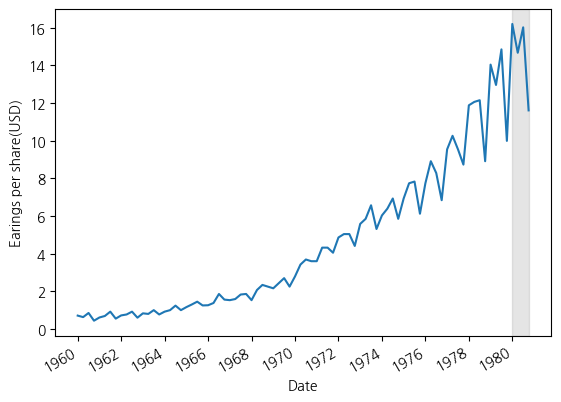

In [298]:
fig, ax = plt.subplots()

ax.plot(df.date, df.data)
ax.set_xlabel('Date')
ax.set_ylabel('Earings per share(USD)')
ax.axvspan(80, 83, color='#808080', alpha=0.2)
plt.xticks(np.arange(0, 81, 8), [1960, 1962, 1964, 1966, 1968, 1970, 1972, 1974, 1976, 1978, 1980])
fig.autofmt_xdate()
plt.show()

In [299]:
train = df[:-4]
test = df[-4:]

In [300]:
train

,date,data
0,1960-01-01,0.71
1,1960-04-01,0.63
2,1960-07-02,0.85
3,1960-10-01,0.44
4,1961-01-01,0.61
...,...,...
75,1978-10-01,8.91
76,1979-01-01,14.04
77,1979-04-02,12.96
78,1979-07-02,14.85


In [301]:
test

,date,data
80,1980-01-01,16.20
81,1980-04-01,14.67
82,1980-07-02,16.02
83,1980-10-01,11.61


In [302]:
hist_mean = np.mean(train['data'])
hist_mean

np.float64(4.308499987499999)

In [303]:
test.loc[:, 'pred_mean'] = hist_mean
test

/tmp/ipykernel_16919/800107886.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test.loc[:, 'pred_mean'] = hist_mean


,date,data,pred_mean
80,1980-01-01,16.20,4.3085
81,1980-04-01,14.67,4.3085
82,1980-07-02,16.02,4.3085
83,1980-10-01,11.61,4.3085


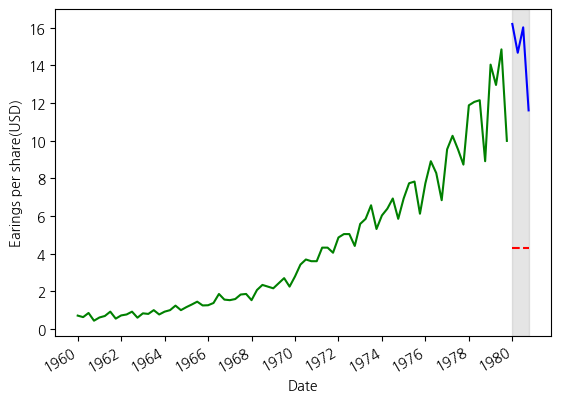

In [304]:
fig, ax = plt.subplots()

ax.plot(train['date'], train['data'], 'g-', label='Train')
ax.plot(test['date'], test['data'], 'b-', label='Test')
ax.plot(test['date'], test['pred_mean'], 'r--', label='Prediction')
ax.set_xlabel('Date')
ax.set_ylabel('Earings per share(USD)')
ax.axvspan(80, 83, color='#808080', alpha=0.2)
plt.xticks(np.arange(0, 81, 8), [1960, 1962, 1964, 1966, 1968, 1970, 1972, 1974, 1976, 1978, 1980])
fig.autofmt_xdate()
plt.show()

In [305]:
last_year_mean = np.mean(train['data'][-4:])
pre_year_data = train['data'].iloc[-1]
val_year_data = train['data'][-4:].values

In [306]:
test.loc[:, 'last_year_mean'] = last_year_mean
test.loc[:, 'pre_year_data'] = pre_year_data
test.loc[:, 'val_year_data'] = val_year_data

/tmp/ipykernel_16919/944470073.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test.loc[:, 'last_year_mean'] = last_year_mean
/tmp/ipykernel_16919/944470073.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test.loc[:, 'pre_year_data'] = pre_year_data
/tmp/ipykernel_16919/944470073.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pand

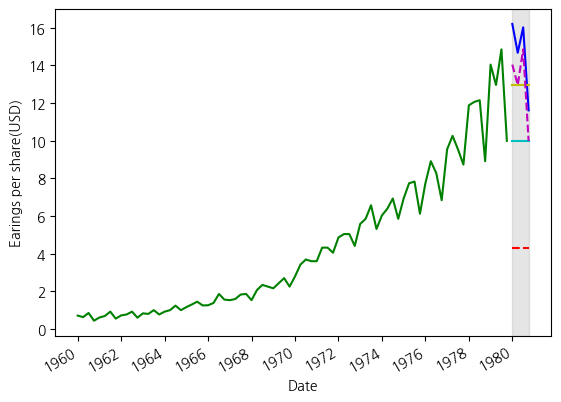

In [307]:
fig, ax = plt.subplots()

ax.plot(train['date'], train['data'], 'g-', label='Train')
ax.plot(test['date'], test['data'], 'b-', label='Test')
ax.plot(test['date'], test['pred_mean'], 'r--', label='Prediction')
ax.plot(test['date'], test['last_year_mean'], 'y-', label='last_year_mean')
ax.plot(test['date'], test['pre_year_data'], 'c-', label='pre_year_data')
ax.plot(test['date'], test['val_year_data'], 'm--', label='val_year_data')
ax.set_xlabel('Date')
ax.set_ylabel('Earings per share(USD)')
ax.axvspan(80, 83, color='#808080', alpha=0.2)
plt.xticks(np.arange(0, 81, 8), [1960, 1962, 1964, 1966, 1968, 1970, 1972, 1974, 1976, 1978, 1980])
fig.autofmt_xdate()
plt.show()